# Phân tích sơ lược dataset căn hộ chung cư Việt Nam

Notebook này dùng để đánh giá nhanh dataset đã lọc từ `tinixai/vietnam-real-estates`, phục vụ bài toán:

**Dự đoán giá căn hộ chung cư dựa trên đặc điểm vật lý, vị trí địa lý, thời gian đăng tin và mô tả tin đăng.**

Mục tiêu của notebook:

1. Kiểm tra kích thước và cấu trúc dữ liệu.
2. Kiểm tra các cột quan trọng cho bài toán dự đoán giá.
3. Phân tích thiếu dữ liệu.
4. Phân tích phân phối giá, diện tích và giá/m².
5. Phát hiện outlier sơ bộ.
6. Phân tích theo vị trí địa lý.
7. Đánh giá khả năng dùng dataset cho mô hình Machine Learning.

In [22]:
# Cài đặt nếu cần:
# !pip install pandas numpy matplotlib pyarrow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = Path("data/vietnam_apartments.parquet")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file {DATA_PATH}. "
        "Hãy đặt notebook này cùng thư mục project và đảm bảo đã chạy script tải dữ liệu trước."
    )

df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (762800, 19)


,name,description,property_type_name,province_name,district_name,ward_name,street_name,project_name,price,area,floor_count,frontage_width,house_depth,road_width,bedroom_count,bathroom_count,house_direction,balcony_direction,published_at
0,"Cần bán căn hộ CC Thái An, Nguyễn Văn Quá, Q12...","Chung cư Thái An đường Nguyễn Văn Quá, Đông Hư...",Căn hộ chung cư,Hồ Chí Minh,12,Đông Hưng Thuận,Nguyễn Văn Quá,Thái An Apartment,"1,300,000,000.00",44.00,NaN,NaN,NaN,NaN,1.00,1.00,NaN,NaN,2025-06-17T05:32:15.491000
1,Bán căn view xéo biển toà OC1B MTVT,"BÁN CĂN HỘ VIEW XÉO BIỂN, Tại địa chỉ : 03 Phạ...",Căn hộ chung cư,Khánh Hòa,Nha Trang,Vĩnh Phước,NaN,Mường Thanh Viễn Triều,"2,650,000,000.00",59.00,NaN,NaN,NaN,NaN,2.00,2.00,NaN,NaN,2025-06-29T13:42:03.190000
2,Bán nhanh căn góc 3 ngủ/90m2 Sunshine Riversid...,Giá tốt bán nhanh căn 3 ngủ chung cư Sunshine ...,Căn hộ chung cư,Hà Nội,Tây Hồ,NaN,NaN,Sunshine Riverside,"7,400,000,000.00",90.00,NaN,NaN,NaN,NaN,3.00,2.00,Đông,NaN,2025-06-04T11:26:05.659000
3,"Căn 3PN Alnata 117m2 view hồ cảnh quan, tầng c...",Hot hot anh chị ơi Căn Diamond Alnata cần chuy...,Căn hộ chung cư,Hồ Chí Minh,Tân Phú,Sơn Kỳ,N1,Diamond Alnata,"7,600,000,000.00",117.00,NaN,NaN,NaN,NaN,3.00,2.00,Tây Nam,Đông Bắc,2025-06-11T05:18:29.915000
4,Chính chủ bán căn hộ 66m² – 2 phòng ngủ full n...,Gia đình chuyển xuống nhà đất cần bán nhanh că...,Căn hộ chung cư,Hà Nội,Thanh Oai,NaN,NaN,Khu đô thị mới Thanh Hà B (Khu đô thị Thanh Hà...,"2,640,000,000.00",66.00,NaN,8.00,8.00,NaN,2.00,2.00,NaN,NaN,2025-06-23T02:17:46.990000


## 1. Thông tin tổng quan

Dataset có **762.800 dòng và 19 cột**. Toàn bộ bản ghi thuộc nhóm `Căn hộ chung cư`, nên phạm vi dữ liệu phù hợp với bài toán dự đoán giá căn hộ.

Các cột chính gồm thông tin giá, diện tích, vị trí, dự án, số phòng, hướng nhà/ban công, thời gian đăng tin và văn bản mô tả. Một số cột có tỷ lệ thiếu cao cần xử lý cẩn thận ở bước mô hình hóa, đặc biệt là `floor_count`, `house_direction`, `balcony_direction`, `street_name` và `project_name`.

In [23]:
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

display(df.head(10))
display(df.info())

Số dòng: 762800
Số cột: 19


,name,description,property_type_name,province_name,district_name,ward_name,street_name,project_name,price,area,floor_count,frontage_width,house_depth,road_width,bedroom_count,bathroom_count,house_direction,balcony_direction,published_at
0,"Cần bán căn hộ CC Thái An, Nguyễn Văn Quá, Q12...","Chung cư Thái An đường Nguyễn Văn Quá, Đông Hư...",Căn hộ chung cư,Hồ Chí Minh,12,Đông Hưng Thuận,Nguyễn Văn Quá,Thái An Apartment,"1,300,000,000.00",44.00,NaN,NaN,NaN,NaN,1.00,1.00,NaN,NaN,2025-06-17T05:32:15.491000
1,Bán căn view xéo biển toà OC1B MTVT,"BÁN CĂN HỘ VIEW XÉO BIỂN, Tại địa chỉ : 03 Phạ...",Căn hộ chung cư,Khánh Hòa,Nha Trang,Vĩnh Phước,NaN,Mường Thanh Viễn Triều,"2,650,000,000.00",59.00,NaN,NaN,NaN,NaN,2.00,2.00,NaN,NaN,2025-06-29T13:42:03.190000
2,Bán nhanh căn góc 3 ngủ/90m2 Sunshine Riversid...,Giá tốt bán nhanh căn 3 ngủ chung cư Sunshine ...,Căn hộ chung cư,Hà Nội,Tây Hồ,NaN,NaN,Sunshine Riverside,"7,400,000,000.00",90.00,NaN,NaN,NaN,NaN,3.00,2.00,Đông,NaN,2025-06-04T11:26:05.659000
3,"Căn 3PN Alnata 117m2 view hồ cảnh quan, tầng c...",Hot hot anh chị ơi Căn Diamond Alnata cần chuy...,Căn hộ chung cư,Hồ Chí Minh,Tân Phú,Sơn Kỳ,N1,Diamond Alnata,"7,600,000,000.00",117.00,NaN,NaN,NaN,NaN,3.00,2.00,Tây Nam,Đông Bắc,2025-06-11T05:18:29.915000
4,Chính chủ bán căn hộ 66m² – 2 phòng ngủ full n...,Gia đình chuyển xuống nhà đất cần bán nhanh că...,Căn hộ chung cư,Hà Nội,Thanh Oai,NaN,NaN,Khu đô thị mới Thanh Hà B (Khu đô thị Thanh Hà...,"2,640,000,000.00",66.00,NaN,8.00,8.00,NaN,2.00,2.00,NaN,NaN,2025-06-23T02:17:46.990000
5,"Bán gấp căn Studio full nội thất, sẵn khách ch...",Gia đình cần bán gấp căn studio diện tích 30m2...,Căn hộ chung cư,Hà Nội,Gia Lâm,NaN,NaN,Vinhomes Ocean Park,"1,800,000,000.00",30.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-10T01:22:36.673000
6,"(Giá thật) chính chủ bán căn 66m2, 3PN + tầng ...",Chuyển nhà xuống biệt thự nên gia đình cần bán...,Căn hộ chung cư,Hà Nội,Thanh Xuân,NaN,NaN,NaN,"5,950,000,000.00",66.00,NaN,NaN,NaN,NaN,2.00,2.00,Đông Nam,Tây Bắc,2025-06-06T04:28:49.097000
7,"Bcons Solary căn 2pn giá chỉ 1,79 tỷ có ngay 3...",Hot: Căn hộ Bcons Solary độc quyền hơn 300 căn...,Căn hộ chung cư,Bình Dương,Dĩ An,Tân Đông Hiệp,Số 4,Bcons Solary,"1,895,400,000.00",52.65,NaN,NaN,NaN,NaN,2.00,2.00,Tây - Bắc,Đông - Nam,2025-06-27T14:25:09.234000
8,"Cơ hội hiếm căn hộ ngoại giao view sông Hàn, g...",Cơ hội hiếm căn hộ ngoại giao view sông Hàn gi...,Căn hộ chung cư,Đà Nẵng,Sơn Trà,Nại Hiên Đông,Lê Văn Duyệt,Peninsula Đà Nẵng (The Muse Đà Nẵng),"3,770,000,000.00",61.80,NaN,NaN,NaN,NaN,2.00,2.00,Đông Bắc,Tây Nam,2025-06-24T10:10:02.416000
9,Ecopark: Bán nhanh căn 72m2 (2pn 2vs) Aquabay ...,Chính chủ gửi bán căn 72m2 Aquabay: Căn hộ có ...,Căn hộ chung cư,Hưng Yên,Văn Giang,Xuân Quan,Trúc,Khu căn hộ Aqua Bay Sky Residence Ecopark,"3,870,000,000.00",72.00,NaN,NaN,NaN,NaN,2.00,2.00,Nam,Bắc,2025-06-24T12:36:06.130000


<class 'pandas.DataFrame'>
RangeIndex: 762800 entries, 0 to 762799
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   name                762800 non-null  str    
 1   description         762800 non-null  str    
 2   property_type_name  762800 non-null  str    
 3   province_name       762800 non-null  str    
 4   district_name       719198 non-null  str    
 5   ward_name           603659 non-null  str    
 6   street_name         398858 non-null  str    
 7   project_name        667159 non-null  str    
 8   price               699785 non-null  float64
 9   area                762798 non-null  float64
 10  floor_count         955 non-null     float64
 11  frontage_width      1128 non-null    float64
 12  house_depth         510 non-null     float64
 13  road_width          273 non-null     float64
 14  bedroom_count       709883 non-null  float64
 15  bathroom_count      682557 non-null  float64


None

In [24]:
# Danh sách cột
pd.DataFrame({
    "column": df.columns,
    "dtype": [df[col].dtype for col in df.columns],
    "missing_count": [df[col].isna().sum() for col in df.columns],
    "missing_percent": [df[col].isna().mean() * 100 for col in df.columns],
    "unique_count": [df[col].nunique(dropna=True) for col in df.columns],
}).sort_values("missing_percent", ascending=False)

,column,dtype,missing_count,missing_percent,unique_count
13,road_width,float64,762527,99.96,42
12,house_depth,float64,762290,99.93,121
10,floor_count,float64,761845,99.87,39
11,frontage_width,float64,761672,99.85,102
17,balcony_direction,str,442110,57.96,15
16,house_direction,str,432623,56.72,17
6,street_name,str,363942,47.71,1617
5,ward_name,str,159141,20.86,708
7,project_name,str,95641,12.54,2857
15,bathroom_count,float64,80243,10.52,25


## 2. Kiểm tra nhãn loại bất động sản

Kết quả kiểm tra cho thấy toàn bộ **762.800 bản ghi** đều có `property_type_name = Căn hộ chung cư`. Như vậy file hiện tại đã được lọc đúng phạm vi căn hộ/chung cư, không phát hiện sai logic ở bước chọn loại bất động sản.

In [25]:
if "property_type_name" in df.columns:
    display(df["property_type_name"].value_counts(dropna=False))
else:
    print("Không có cột property_type_name")

property_type_name
Căn hộ chung cư    762800
Name: count, dtype: int64

## 3. Kiểm tra các cột quan trọng cho bài toán dự đoán giá

Dataset có đủ các nhóm cột quan trọng cho mô hình dự đoán giá:

- Biến mục tiêu: `price`.
- Diện tích: `area`.
- Vị trí: `province_name`, `district_name`, `ward_name`, `street_name`.
- Dự án: `project_name`.
- Đặc điểm vật lý: `bedroom_count`, `bathroom_count`, `floor_count`.
- Hướng: `house_direction`, `balcony_direction`.
- Thời gian và văn bản: `published_at`, `name`, `description`.

Nhận xét từ dữ liệu thực tế: `price` thiếu khoảng **8,26%**, `area` gần như không thiếu, `project_name` thiếu khoảng **12,54%**, `description` và `name` không thiếu. `floor_count` thiếu gần như toàn bộ nên không nên xem là đặc trưng chính nếu chưa có bước trích xuất bổ sung từ mô tả. `house_direction` và `balcony_direction` thiếu trên 50%, chỉ nên dùng như biến phụ hoặc nhóm `Unknown`.

In [26]:
important_cols = [
    "price", "area",
    "province_name", "district_name", "ward_name", "street_name", "project_name",
    "bedroom_count", "bathroom_count", "floor_count",
    "house_direction", "balcony_direction",
    "published_at",
    "name", "description"
]

available_cols = [col for col in important_cols if col in df.columns]
missing_important_cols = [col for col in important_cols if col not in df.columns]

print("Cột quan trọng có trong dataset:")
print(available_cols)

print("\nCột quan trọng chưa thấy trong dataset:")
print(missing_important_cols)

summary_important = pd.DataFrame({
    "column": available_cols,
    "dtype": [df[col].dtype for col in available_cols],
    "missing_count": [df[col].isna().sum() for col in available_cols],
    "missing_percent": [df[col].isna().mean() * 100 for col in available_cols],
    "unique_count": [df[col].nunique(dropna=True) for col in available_cols],
})

display(summary_important.sort_values("missing_percent", ascending=False))

Cột quan trọng có trong dataset:
['price', 'area', 'province_name', 'district_name', 'ward_name', 'street_name', 'project_name', 'bedroom_count', 'bathroom_count', 'floor_count', 'house_direction', 'balcony_direction', 'published_at', 'name', 'description']

Cột quan trọng chưa thấy trong dataset:
[]


,column,dtype,missing_count,missing_percent,unique_count
9,floor_count,float64,761845,99.87,39
11,balcony_direction,str,442110,57.96,15
10,house_direction,str,432623,56.72,17
5,street_name,str,363942,47.71,1617
4,ward_name,str,159141,20.86,708
6,project_name,str,95641,12.54,2857
8,bathroom_count,float64,80243,10.52,25
0,price,float64,63015,8.26,13377
7,bedroom_count,float64,52917,6.94,25
3,district_name,str,43602,5.72,198


## 4. Làm sạch tạm thời để phân tích EDA

Ở bước này chưa phải làm sạch chính thức cho mô hình. Ta chỉ tạo bản `eda_df` và `eda_valid` để phân tích phân phối hợp lý hơn.

Sau khi lọc các dòng có `price > 0` và `area > 0`, còn **677.895 dòng**, tương đương khoảng **88,87%** dữ liệu ban đầu. Cách lọc này hợp lý cho EDA vì `price` là biến mục tiêu và `area` là biến nền để tính `price_per_m2`.

In [27]:
eda_df = df.copy()

# Ép kiểu các cột số quan trọng nếu tồn tại
numeric_cols = [
    "price", "area", "bedroom_count", "bathroom_count",
    "floor_count", "frontage_width", "road_width"
]

for col in numeric_cols:
    if col in eda_df.columns:
        eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

# Tạo price_per_m2 để phân tích
if {"price", "area"}.issubset(eda_df.columns):
    eda_df["price_per_m2"] = eda_df["price"] / eda_df["area"]
else:
    print("Không đủ cột price và area để tạo price_per_m2")

print("Shape trước lọc tạm:", eda_df.shape)

# Lọc tạm các dòng có price và area hợp lệ
if {"price", "area"}.issubset(eda_df.columns):
    eda_valid = eda_df[
        (eda_df["price"].notna()) &
        (eda_df["area"].notna()) &
        (eda_df["price"] > 0) &
        (eda_df["area"] > 0)
    ].copy()

    print("Shape sau lọc price/area hợp lệ:", eda_valid.shape)
    print("Tỷ lệ giữ lại:", len(eda_valid) / len(eda_df) * 100, "%")
else:
    eda_valid = eda_df.copy()

Shape trước lọc tạm: (762800, 20)
Shape sau lọc price/area hợp lệ: (677895, 20)
Tỷ lệ giữ lại: 88.86929732564238 %


## 5. Thống kê mô tả cho giá, diện tích, giá/m²

Phân phối giá, diện tích và giá/m² bị lệch phải rất mạnh:

- Giá trung vị khoảng **4,9 tỷ VND**, nhưng giá trị lớn nhất lên tới gần **999.910 tỷ VND**, cho thấy có cực trị hoặc lỗi nhập liệu.
- Diện tích trung vị khoảng **73 m²**, trong khi giá trị lớn nhất lên tới **82.000.000 m²**, chắc chắn cần xử lý outlier.
- Giá/m² trung vị khoảng **68 triệu VND/m²**; các percentile cao tăng rất nhanh.

Vì vậy khi xây mô hình regression, nên thử dự đoán `log(price)` hoặc `log1p(price)` thay vì giá gốc để giảm ảnh hưởng của phân phối lệch và outlier.

In [28]:
cols_to_describe = [col for col in ["price", "area", "price_per_m2", "bedroom_count", "bathroom_count", "floor_count"] if col in eda_valid.columns]

display(eda_valid[cols_to_describe].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price,"677,895.00","10,763,369,683.56","1,721,839,136,189.53","2,000.00","1,100,000,000.00","1,750,000,000.00","3,150,000,000.00","4,900,000,000.00","7,800,000,000.00","16,500,000,000.00","37,000,000,000.00","999,910,000,000,000.00"
area,"677,895.00",262.63,"109,781.74",3.00,30.00,42.00,60.00,73.00,94.00,143.00,235.00,"82,000,000.00"
price_per_m2,"677,895.00","86,490,286.25","1,019,288,742.01",15.00,"21,142,857.14","30,882,352.94","50,000,000.00","68,000,000.00","90,000,000.00","144,736,842.11","261,864,406.78","348,571,428,571.43"
bedroom_count,"634,681.00",2.24,0.74,1.00,1.00,1.00,2.00,2.00,3.00,3.00,4.00,73.00
bathroom_count,"611,436.00",1.85,0.58,1.00,1.00,1.00,2.00,2.00,2.00,3.00,4.00,73.00
floor_count,864.00,12.25,12.85,1.00,1.00,1.00,2.00,6.00,22.00,36.00,40.00,45.00


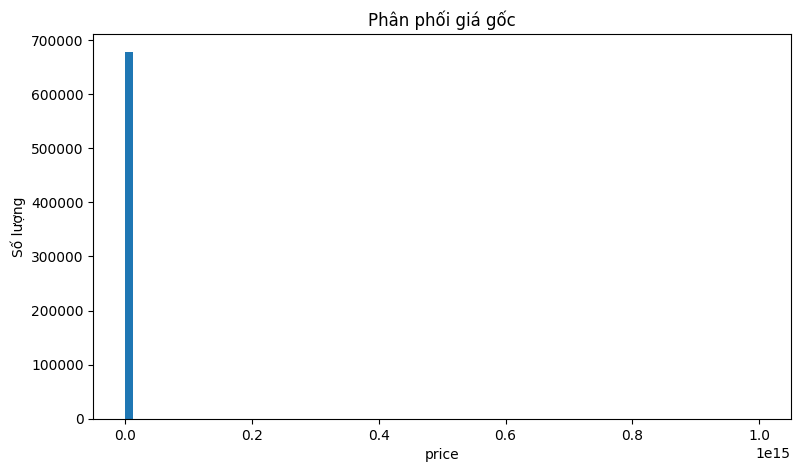

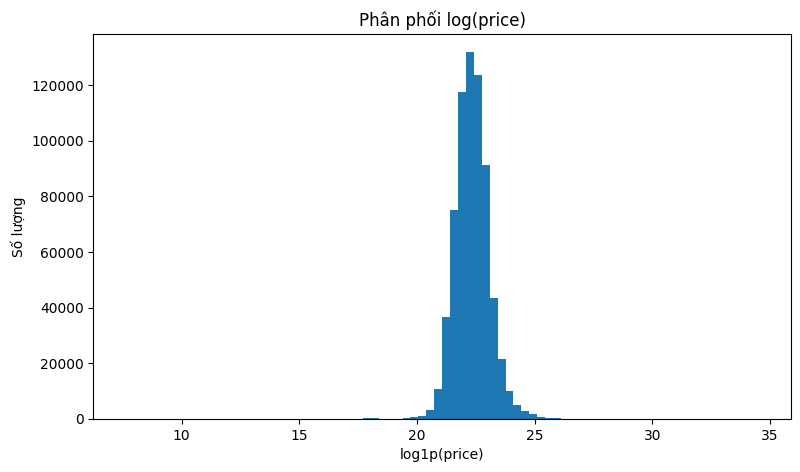

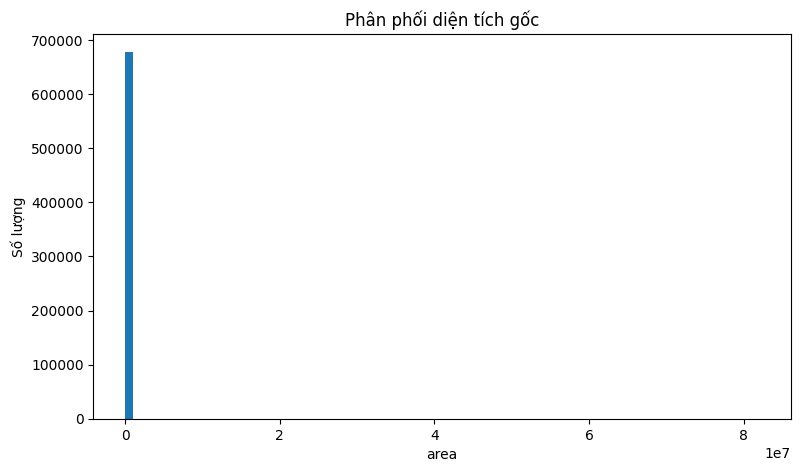

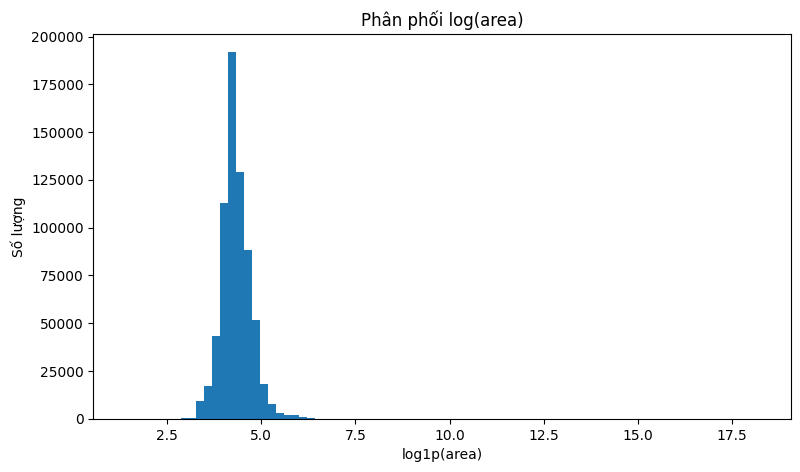

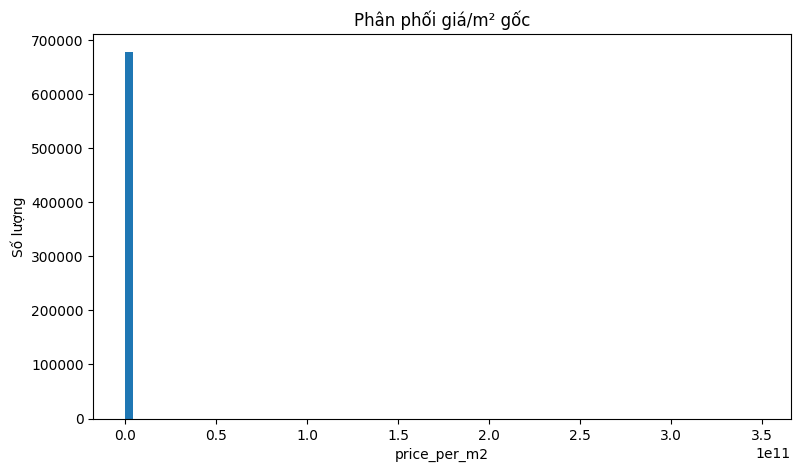

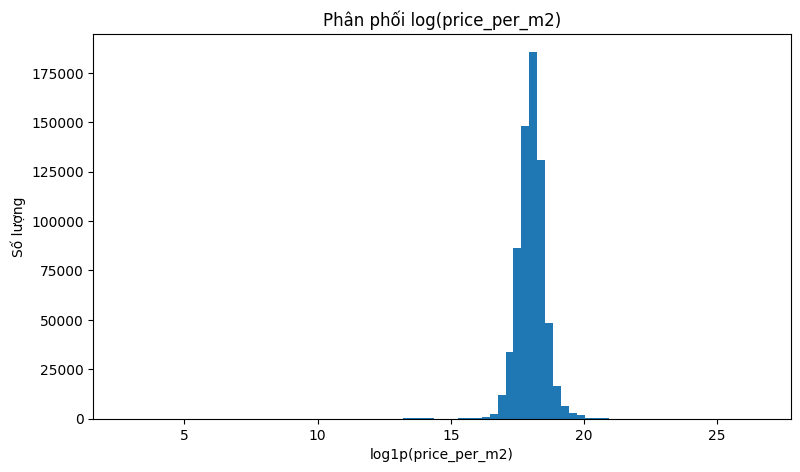

In [29]:
# Hàm vẽ histogram đơn giản

def plot_hist(series, title, xlabel, bins=80, log_x=False):
    s = series.dropna()
    if log_x:
        s = s[s > 0]
        s = np.log1p(s)
        xlabel = "log1p(" + xlabel + ")"

    plt.figure(figsize=(9, 5))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Số lượng")
    plt.show()

if "price" in eda_valid.columns:
    plot_hist(eda_valid["price"], "Phân phối giá gốc", "price")
    plot_hist(eda_valid["price"], "Phân phối log(price)", "price", log_x=True)

if "area" in eda_valid.columns:
    plot_hist(eda_valid["area"], "Phân phối diện tích gốc", "area")
    plot_hist(eda_valid["area"], "Phân phối log(area)", "area", log_x=True)

if "price_per_m2" in eda_valid.columns:
    plot_hist(eda_valid["price_per_m2"], "Phân phối giá/m² gốc", "price_per_m2")
    plot_hist(eda_valid["price_per_m2"], "Phân phối log(price_per_m2)", "price_per_m2", log_x=True)

## 6. Phát hiện outlier sơ bộ

Không nên xóa outlier ngay theo cảm tính. Ở đây notebook chỉ thống kê để quyết định quy tắc làm sạch sau này.

Theo ngưỡng percentile 1%–99%:

- `area` hợp lý sơ bộ nằm trong khoảng **30–235 m²**.
- `price_per_m2` hợp lý sơ bộ nằm trong khoảng khoảng **21,14–261,86 triệu VND/m²**.
- Có **23.678 dòng** bị gắn cờ outlier sơ bộ, tương đương khoảng **3,49%** của `eda_valid`.

Logic lọc theo percentile là chấp nhận được cho baseline, nhưng khi viết báo cáo nên nói rõ đây là quy tắc thực nghiệm, không phải chuẩn nghiệp vụ tuyệt đối.

In [30]:
if {"price", "area", "price_per_m2"}.issubset(eda_valid.columns):
    q = eda_valid[["price", "area", "price_per_m2"]].quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
    display(q)

    # Gợi ý ngưỡng lọc theo percentile
    p01_area = eda_valid["area"].quantile(0.01)
    p99_area = eda_valid["area"].quantile(0.99)

    p01_ppm2 = eda_valid["price_per_m2"].quantile(0.01)
    p99_ppm2 = eda_valid["price_per_m2"].quantile(0.99)

    print("Gợi ý ngưỡng lọc tạm:")
    print(f"area từ {p01_area:,.2f} đến {p99_area:,.2f}")
    print(f"price_per_m2 từ {p01_ppm2:,.2f} đến {p99_ppm2:,.2f}")

    outlier_flag = (
        (eda_valid["area"] < p01_area) |
        (eda_valid["area"] > p99_area) |
        (eda_valid["price_per_m2"] < p01_ppm2) |
        (eda_valid["price_per_m2"] > p99_ppm2)
    )

    print("Số dòng outlier sơ bộ:", outlier_flag.sum())
    print("Tỷ lệ outlier sơ bộ:", outlier_flag.mean() * 100, "%")
else:
    print("Không đủ cột để phân tích outlier")

,price,area,price_per_m2
0.00,"320,000,000.00",25.00,"8,083,333.33"
0.01,"1,100,000,000.00",30.00,"21,142,857.14"
0.05,"1,750,000,000.00",42.00,"30,882,352.94"
0.50,"4,900,000,000.00",73.00,"68,000,000.00"
0.95,"16,500,000,000.00",143.00,"144,736,842.11"
0.99,"37,000,000,000.00",235.00,"261,864,406.78"
1.00,"110,000,000,000.00",470.00,"554,699,636.36"


Gợi ý ngưỡng lọc tạm:
area từ 30.00 đến 235.00
price_per_m2 từ 21,142,857.14 đến 261,864,406.78
Số dòng outlier sơ bộ: 23678
Tỷ lệ outlier sơ bộ: 3.4928713148791477 %


In [31]:
# Xem vài dòng có giá/m2 cực thấp và cực cao để kiểm tra lỗi dữ liệu
if "price_per_m2" in eda_valid.columns:
    display(
        eda_valid.sort_values("price_per_m2", ascending=True)
        .head(20)[[col for col in ["name", "price", "area", "price_per_m2", "province_name", "district_name", "ward_name", "project_name"] if col in eda_valid.columns]]
    )

    display(
        eda_valid.sort_values("price_per_m2", ascending=False)
        .head(20)[[col for col in ["name", "price", "area", "price_per_m2", "province_name", "district_name", "ward_name", "project_name"] if col in eda_valid.columns]]
    )

,name,price,area,price_per_m2,province_name,district_name,ward_name,project_name
477007,"Chung cư xã hội Định Hòa, lầu 2 giá : 570 triệ...","570,000,000.00","38,000,000.00",15.00,Bình Dương,Thủ Dầu Một,Định Hòa,Becamex Định Hòa
714124,Duy nhất căn 1Br+ Áp Góc view Đại Lộ Hoa giá 1...,"2,000.00",46.60,42.92,Hà Nam,Phủ Lý,Lam Hạ,Sun Urban City Hà Nam
699854,CĂN HỘ TRUNG TÂM ĐÀ NẴNG VIEW SÔNG GIÁ CHỈ TỪ ...,"2,000.00",45.00,44.44,Đà Nẵng,Ngũ Hành Sơn,Hòa Quý,Star Tower
666814,Bán Tập Thể Thuốc Lá Thanh Xuân - 60m2 - 2PN 2...,"3,000.00",65.00,46.15,Hà Nội,Thanh Xuân,Khương Đình,NaN
740075,BÁN CĂN 1PN XH1 VCN PHƯỚC LONG ĐẸP VÀO Ở NGAY ...,"2,000.00",42.00,47.62,Khánh Hòa,Nha Trang,Phước Long,NaN
704554,"Căn hộ Đức Khải sổ hồng căn góc 72m2 2PN,2wc g...","4,000.00",72.00,55.56,Hồ Chí Minh,7,Phú Mỹ,The Era Town
727415,"Chung cư Ngô Quyền Q5- 78,5m2- 3PN-2WC- giá 4,...","4,390.00",78.50,55.92,Hồ Chí Minh,5,9,NaN
577011,Sun Garden Đà Lạt bán căn góc 65m2 view thung ...,"3,799.00",65.00,58.45,Lâm Đồng,Đà Lạt,11,Sun Garden Đà Lạt
241720,CĂN 4PN RẺ NHẤT ĐẸP NHẤT MASTERI TRINITY SQUAR...,"6,927.00",116.00,59.72,Hưng Yên,Văn Giang,Long Hưng,Vinhomes Ocean Park 2 – The Empire
586670,Cần tiền bán gấp 2N1w 55m Full NT Luxury giá c...,"3,580.00",55.00,65.09,Hà Nội,Gia Lâm,Đa Tốn,The Sapphire 1 - Vinhomes Ocean Park


,name,price,area,price_per_m2,province_name,district_name,ward_name,project_name
713738,K BÁO GIÁ ẢO- Cập nhật giá bán mới nhất THE OP...,"24,400,000,000,000.00",70.00,"348,571,428,571.43",Hồ Chí Minh,Thủ Đức,An Khánh,The Opera Residence
487007,"Căn góc 2pn+1wc giá 1ty7 view hồ bơi, mặt tiền...","15,157,220,000,000.00",50.44,"300,500,000,000.00",Long An,Bến Lức,Mỹ Yên,Destino Centro
119483,Bán Narra Empire City. Loại căn 3PN thiết kế c...,"26,500,000,000,000.00",115.00,"230,434,782,608.70",Hồ Chí Minh,Thủ Đức,Thủ Thiêm,Empire City Thủ Thiêm
102617,HOT DEAL The Grand Manhattan Quận 1 Căn hộ 2PN...,"11,700,000,000,000.00",68.10,"171,806,167,400.88",Hồ Chí Minh,1,Cô Giang,The Grand Manhattan
304493,Bán gấp căn 1 ngủ + 1 tại dự án The Legend Đà ...,"9,000,000,000,000.00",58.00,"155,172,413,793.10",Đà Nẵng,Sơn Trà,NaN,The Legend City
712135,Cập nhật rổ hàng CĐT và rổ hàng chuyển nhượng ...,"10,400,000,000,000.00",75.20,"138,297,872,340.43",Hồ Chí Minh,Thủ Đức,An Phú,Eaton Park Residence
670604,Cập nhật rổ hàng CĐT và rổ hàng chuyển nhượng ...,"10,400,000,000,000.00",75.20,"138,297,872,340.43",Hồ Chí Minh,Thủ Đức,An Phú,Eaton Park Residence
754693,"Bán gấp căn hộ 2PN, 2WC tại Vinhomes D'Capital...","9,300,000,000,000.00",72.00,"129,166,666,666.67",Hà Nội,Cầu Giấy,Trung Hòa,Chung cư D'Capitale
728416,Căn Ngoại Giao 140m 3pn Full Nội Thất Green Di...,"16,800,000,000,000.00",140.00,"120,000,000,000.00",Hà Nội,Đống Đa,Láng Hạ,Green Diamond 93 Láng Hạ
68804,Bán căn 3PN view hồ tầng trung đẹp nhất dự án ...,"13,666,000,000,000.00",116.00,"117,810,344,827.59",Hà Nội,Nam Từ Liêm,Mễ Trì,The Matrix One


## 7. Phân tích theo địa lý

Dữ liệu tập trung rất mạnh ở một số thị trường lớn. Hai tỉnh/thành có nhiều tin nhất là **Hồ Chí Minh** với khoảng **265.059 tin** và **Hà Nội** với khoảng **257.639 tin**; tiếp theo là Bình Dương, Đà Nẵng, Hưng Yên và Khánh Hòa.

Thiên lệch địa lý này là tín hiệu quan trọng: mô hình có thể hoạt động tốt hơn ở Hà Nội/TP.HCM so với các tỉnh có ít mẫu. Nếu mục tiêu là dự đoán cho toàn Việt Nam, cần đánh giá riêng theo tỉnh/thành hoặc dùng chiến lược chia tập kiểm tra có kiểm soát theo địa lý.

In [32]:
def top_count(col, n=20):
    if col in eda_valid.columns:
        tmp = eda_valid[col].value_counts(dropna=False).head(n).reset_index()
        tmp.columns = [col, "count"]
        display(tmp)
    else:
        print(f"Không có cột {col}")

top_count("province_name", 20)
top_count("district_name", 20)
top_count("ward_name", 20)
top_count("project_name", 20)

,province_name,count
0,Hồ Chí Minh,265059
1,Hà Nội,257639
2,Bình Dương,51883
3,Đà Nẵng,23000
4,Hưng Yên,21696
5,Khánh Hòa,14249
6,Hải Phòng,7375
7,Bà Rịa - Vũng Tàu,5593
8,Long An,5056
9,Quảng Ninh,4974


,district_name,count
0,Thủ Đức,50062
1,7,47485
2,Nam Từ Liêm,44970
3,NaN,40662
4,Cầu Giấy,31778
5,Hoàng Mai,28698
6,Hà Đông,27689
7,Thanh Xuân,25529
8,Dĩ An,22888
9,Thuận An,21276


,ward_name,count
0,NaN,145094
1,Tân Phú,16022
2,Tây Mỗ,12699
3,Xuân Quan,10051
4,An Phú,9962
5,Phú Mỹ,8995
6,Long Thạnh Mỹ,8898
7,Sơn Kỳ,8273
8,Nhân Chính,7829
9,Trung Hòa,7399


,project_name,count
0,NaN,87446
1,Vinhomes Ocean Park,8208
2,The Origami – Vinhomes Grand Park,3999
3,Masteri Trinity Square,3520
4,Sun Urban City Hà Nam,3481
5,MT Eastmark City,3090
6,Mizuki Park,2948
7,Vinhomes Central Park,2937
8,Masteri Waterfront,2932
9,The Sun Avenue,2916


In [33]:
# Giá trung vị và giá/m2 trung vị theo tỉnh/thành
group_cols = ["province_name", "district_name", "project_name"]

for col in group_cols:
    if col in eda_valid.columns and {"price", "area", "price_per_m2"}.issubset(eda_valid.columns):
        summary = (
            eda_valid
            .groupby(col)
            .agg(
                count=("price", "size"),
                median_price=("price", "median"),
                median_area=("area", "median"),
                median_price_per_m2=("price_per_m2", "median")
            )
            .reset_index()
            .sort_values("count", ascending=False)
        )

        print(f"\nThống kê theo {col}:")
        display(summary.head(30))


Thống kê theo province_name:


,province_name,count,median_price,median_area,median_price_per_m2
20,Hồ Chí Minh,265059,"5,000,000,000.00",75.00,"66,216,216.22"
13,Hà Nội,257639,"6,500,000,000.00",80.00,"80,357,142.86"
2,Bình Dương,51883,"2,390,000,000.00",58.00,"39,583,333.33"
48,Đà Nẵng,23000,"4,400,000,000.00",65.00,"68,493,150.68"
16,Hưng Yên,21696,"4,200,000,000.00",64.60,"66,666,666.67"
21,Khánh Hòa,14249,"3,200,000,000.00",65.00,"49,319,727.89"
18,Hải Phòng,7375,"2,500,000,000.00",63.90,"39,759,036.14"
1,Bà Rịa - Vũng Tàu,5593,"2,800,000,000.00",68.00,"41,447,368.42"
23,Long An,5056,"1,500,000,000.00",50.00,"30,555,555.56"
35,Quảng Ninh,4974,"2,500,000,000.00",58.00,"44,905,660.38"



Thống kê theo district_name:


,district_name,count,median_price,median_area,median_price_per_m2
144,Thủ Đức,50062,"5,600,000,000.00",73.00,"73,869,403.41"
8,7,47485,"6,500,000,000.00",85.00,"75,438,596.49"
91,Nam Từ Liêm,44970,"6,816,000,000.00",80.60,"84,615,384.62"
41,Cầu Giấy,31778,"9,000,000,000.00",95.00,"92,222,222.22"
57,Hoàng Mai,28698,"5,300,000,000.00",72.00,"72,601,626.02"
60,Hà Đông,27689,"5,400,000,000.00",79.00,"65,217,391.30"
134,Thanh Xuân,25529,"8,100,000,000.00",90.00,"92,500,000.00"
49,Dĩ An,22888,"2,350,000,000.00",55.00,"40,888,888.89"
135,Thuận An,21276,"2,400,000,000.00",61.00,"38,727,798.21"
168,Văn Giang,21016,"4,250,000,000.00",65.00,"67,010,309.28"



Thống kê theo project_name:


,project_name,count,median_price,median_area,median_price_per_m2
2691,Vinhomes Ocean Park,8208,"3,650,000,000.00",55.00,"67,520,000.00"
2384,The Origami – Vinhomes Grand Park,3999,"3,350,000,000.00",67.00,"53,125,000.00"
1621,Masteri Trinity Square,3520,"3,600,000,000.00",60.00,"62,903,225.81"
2139,Sun Urban City Hà Nam,3481,"1,600,000,000.00",45.00,"37,777,777.78"
1594,MT Eastmark City,3090,"3,300,000,000.00",65.00,"50,000,000.00"
1646,Mizuki Park,2948,"4,350,000,000.00",76.00,"59,302,325.58"
2674,Vinhomes Central Park,2937,"11,400,000,000.00",89.10,"126,495,726.50"
1622,Masteri Waterfront,2932,"4,210,000,000.00",55.30,"78,125,000.00"
2437,The Sun Avenue,2916,"7,200,000,000.00",75.00,"91,772,151.90"
1672,Mường Thanh Viễn Triều,2761,"3,300,000,000.00",62.00,"52,112,676.06"


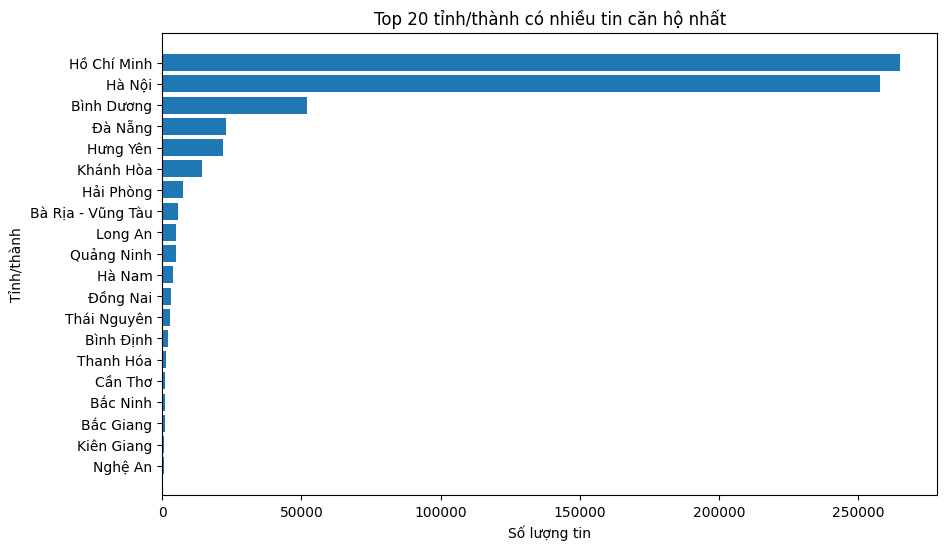

In [34]:
# Vẽ top tỉnh/thành theo số lượng tin
if "province_name" in eda_valid.columns:
    province_counts = eda_valid["province_name"].value_counts().head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(province_counts.index[::-1], province_counts.values[::-1])
    plt.title("Top 20 tỉnh/thành có nhiều tin căn hộ nhất")
    plt.xlabel("Số lượng tin")
    plt.ylabel("Tỉnh/thành")
    plt.show()

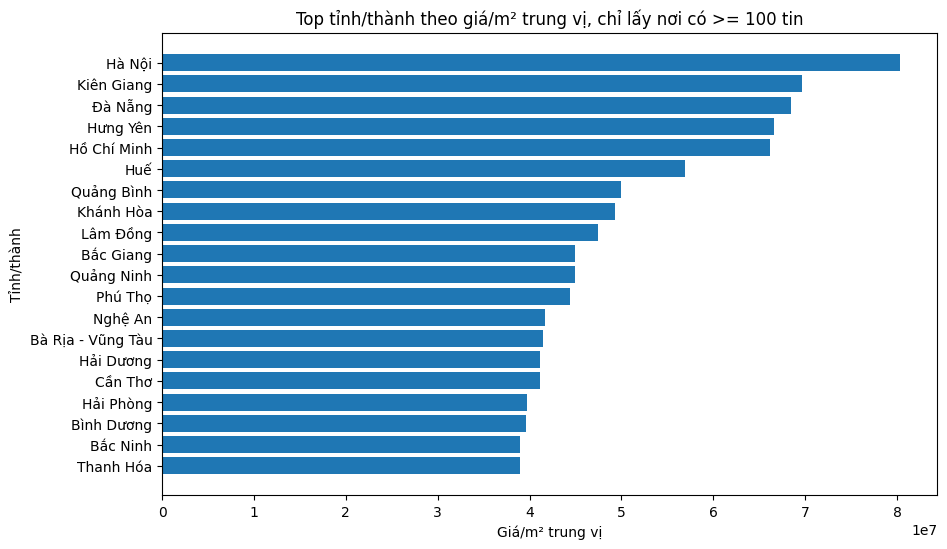

In [35]:
# Vẽ giá/m2 trung vị theo top tỉnh/thành có đủ số mẫu
if {"province_name", "price_per_m2"}.issubset(eda_valid.columns):
    province_summary = (
        eda_valid
        .groupby("province_name")
        .agg(
            count=("price_per_m2", "size"),
            median_price_per_m2=("price_per_m2", "median")
        )
        .reset_index()
    )

    min_samples = 100
    province_summary = province_summary[province_summary["count"] >= min_samples]
    province_summary = province_summary.sort_values("median_price_per_m2", ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(province_summary["province_name"][::-1], province_summary["median_price_per_m2"][::-1])
    plt.title(f"Top tỉnh/thành theo giá/m² trung vị, chỉ lấy nơi có >= {min_samples} tin")
    plt.xlabel("Giá/m² trung vị")
    plt.ylabel("Tỉnh/thành")
    plt.show()

### 7.1. Phân tích thêm theo đường/phố

`street_name` là feature vị trí có độ chi tiết cao hơn quận/huyện và phường/xã, nhưng thiếu khá nhiều: trong `eda_valid`, cột này thiếu khoảng **48,20%** và có **1.567** giá trị khác nhau.

Các đường xuất hiện nhiều gồm Nguyễn Văn Linh, Nguyễn Hữu Thọ, Nguyễn Lương Bằng, Tố Hữu, Phạm Hùng, Lê Văn Lương... Giá/m² trung vị giữa các đường có khác biệt lớn, nên `street_name` có thể hữu ích cho mô hình nếu được mã hóa phù hợp. Tuy nhiên do tỷ lệ thiếu cao và cardinality lớn, không nên one-hot trực tiếp toàn bộ; nên cân nhắc target encoding/catboost encoding, gom nhóm đường hiếm, hoặc dùng `Unknown` cho giá trị thiếu.

In [36]:
if "street_name" in eda_valid.columns:
    street_missing = eda_valid["street_name"].isna().mean() * 100
    street_unique = eda_valid["street_name"].nunique(dropna=True)
    print(f"Tỷ lệ thiếu street_name: {street_missing:.2f}%")
    print(f"Số street_name khác nhau: {street_unique:,}")

    top_streets = eda_valid["street_name"].value_counts(dropna=False).head(20).reset_index()
    top_streets.columns = ["street_name", "count"]
    display(top_streets)

    if "price_per_m2" in eda_valid.columns:
        street_summary = (
            eda_valid
            .groupby("street_name", dropna=False)
            .agg(
                count=("price_per_m2", "size"),
                median_price=("price", "median"),
                median_price_per_m2=("price_per_m2", "median")
            )
            .reset_index()
            .sort_values("count", ascending=False)
        )
        display(street_summary.head(30))

        min_samples = 500
        street_price_rank = (
            street_summary[street_summary["count"] >= min_samples]
            .sort_values("median_price_per_m2", ascending=False)
            .head(20)
        )
        display(street_price_rank)
else:
    print("Không có cột street_name")

Tỷ lệ thiếu street_name: 48.20%
Số street_name khác nhau: 1,567


,street_name,count
0,NaN,326716
1,Nguyễn Văn Linh,9356
2,Nguyễn Hữu Thọ,8684
3,Nguyễn Lương Bằng,7695
4,Tố Hữu,7694
5,N1,6729
6,Phạm Hùng,6227
7,Lê Văn Lương,6166
8,Trúc,5251
9,Nguyễn Hữu Cảnh,4854


,street_name,count,median_price,median_price_per_m2
1567,NaN,326716,"4,650,000,000.00","66,989,507.67"
842,Nguyễn Văn Linh,9356,"4,268,000,000.00","59,883,720.93"
770,Nguyễn Hữu Thọ,8684,"5,300,000,000.00","68,641,975.31"
785,Nguyễn Lương Bằng,7695,"6,450,000,000.00","79,120,879.12"
1325,Tố Hữu,7694,"6,500,000,000.00","71,419,642.86"
703,N1,6729,"6,850,000,000.00","68,309,859.15"
979,Phạm Hùng,6227,"8,900,000,000.00","100,000,000.00"
619,Lê Văn Lương,6166,"8,000,000,000.00","90,000,000.00"
1170,Trúc,5251,"4,750,000,000.00","71,666,666.67"
768,Nguyễn Hữu Cảnh,4854,"11,000,000,000.00","114,694,122.35"


,street_name,count,median_price,median_price_per_m2
1303,Tôn Đức Thắng,3197,"23,900,000,000.00","312,500,000.00"
870,Nguyễn Đình Chiểu,1549,"13,700,000,000.00","196,153,846.15"
558,Liễu Giai,922,"17,500,000,000.00","189,189,189.19"
840,Nguyễn Văn Huyên,646,"29,400,000,000.00","176,607,387.14"
1346,Võ Chí Công,630,"9,995,000,000.00","136,024,096.39"
566,Láng Hạ,1353,"13,212,000,000.00","124,305,555.56"
596,Lê Quang Đạo,1580,"13,000,000,000.00","119,318,181.82"
1463,Điện Biên Phủ,2368,"10,775,000,000.00","118,905,940.59"
1406,Xuân Thủy,1808,"11,000,000,000.00","118,394,199.79"
768,Nguyễn Hữu Cảnh,4854,"11,000,000,000.00","114,694,122.35"


## 8. Phân tích đặc điểm vật lý

Số phòng ngủ và phòng tắm có phân phối phù hợp với căn hộ chung cư: phần lớn là căn **2 phòng ngủ** và **2 phòng tắm**, tiếp theo là nhóm 1–3 phòng.

Tuy nhiên vẫn có các giá trị rất lớn như 73 phòng ngủ/phòng tắm, khả năng cao là lỗi nhập liệu hoặc tin đặc biệt. `floor_count` thiếu gần như toàn bộ nên giá trị sử dụng trực tiếp thấp; nếu cần thông tin tầng, nên trích xuất thêm từ `name` hoặc `description`.


Phân phối bedroom_count:


bedroom_count
1.00      79377
2.00     350677
3.00     182183
4.00      19285
5.00       2658
6.00        367
7.00         42
8.00         30
9.00         11
10.00        11
11.00         3
12.00        10
13.00         4
16.00         2
18.00         7
19.00         1
20.00         4
21.00         3
23.00         1
30.00         1
34.00         1
36.00         1
42.00         1
73.00         1
NaN       43214
Name: count, dtype: int64

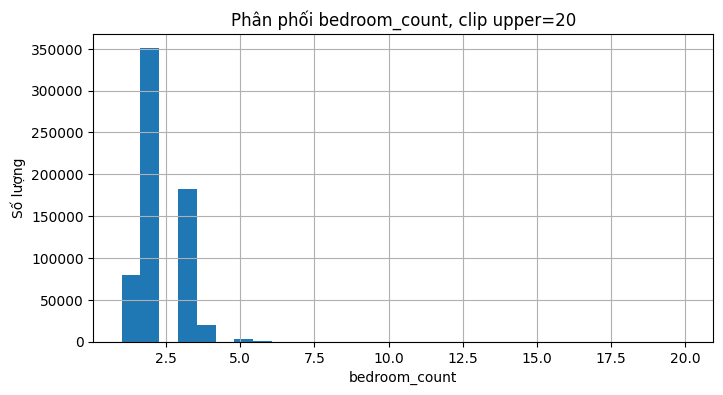


Phân phối bathroom_count:


bathroom_count
1.00     137370
2.00     438011
3.00      28583
4.00       5924
5.00       1230
6.00        176
7.00         86
8.00          6
9.00          6
10.00        12
11.00         5
12.00         5
13.00         2
14.00         1
16.00         1
18.00         7
19.00         1
20.00         3
21.00         2
23.00         1
30.00         1
34.00         1
37.00         1
73.00         1
NaN       66459
Name: count, dtype: int64

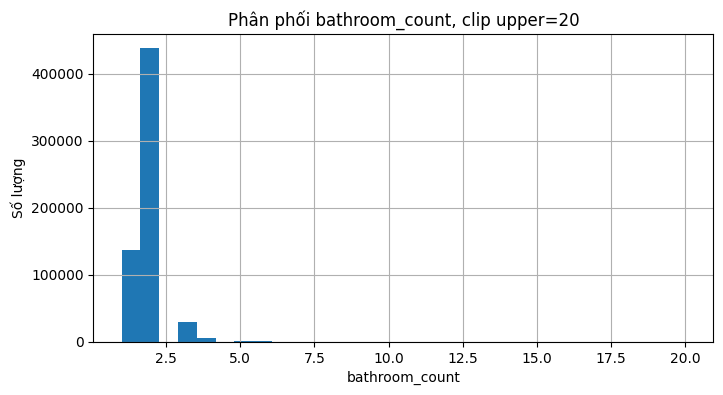


Phân phối floor_count:


floor_count
1.00        169
2.00        124
3.00         46
4.00         31
5.00         61
6.00         30
7.00         43
8.00         27
9.00          8
10.00         5
11.00         7
12.00         5
14.00         3
15.00         8
16.00        24
17.00         6
18.00         6
19.00        18
20.00        15
21.00         5
22.00        13
23.00         2
24.00         4
25.00        16
26.00         4
27.00         8
28.00        17
29.00        11
30.00         8
31.00         4
32.00         1
33.00        26
34.00        55
35.00         4
36.00        17
39.00         7
40.00        24
41.00         1
45.00         1
NaN      677031
Name: count, dtype: int64

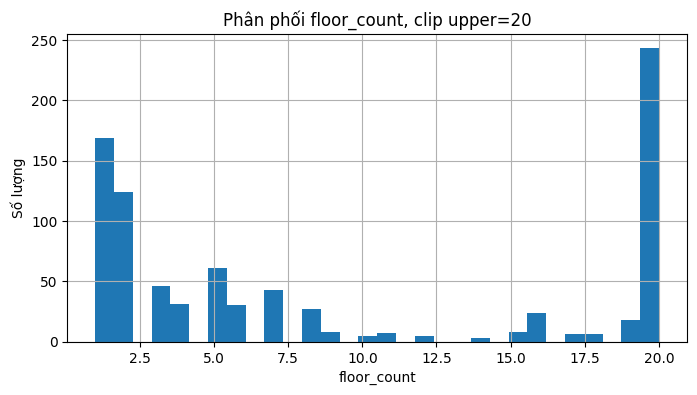

In [37]:
for col in ["bedroom_count", "bathroom_count", "floor_count"]:
    if col in eda_valid.columns:
        print(f"\nPhân phối {col}:")
        display(eda_valid[col].value_counts(dropna=False).sort_index().head(50))

        plt.figure(figsize=(8, 4))
        eda_valid[col].dropna().clip(upper=20).hist(bins=30)
        plt.title(f"Phân phối {col}, clip upper=20")
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plt.show()

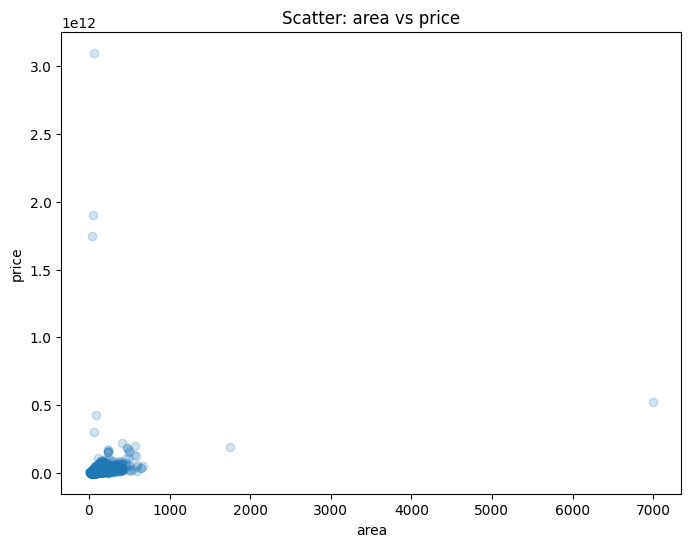

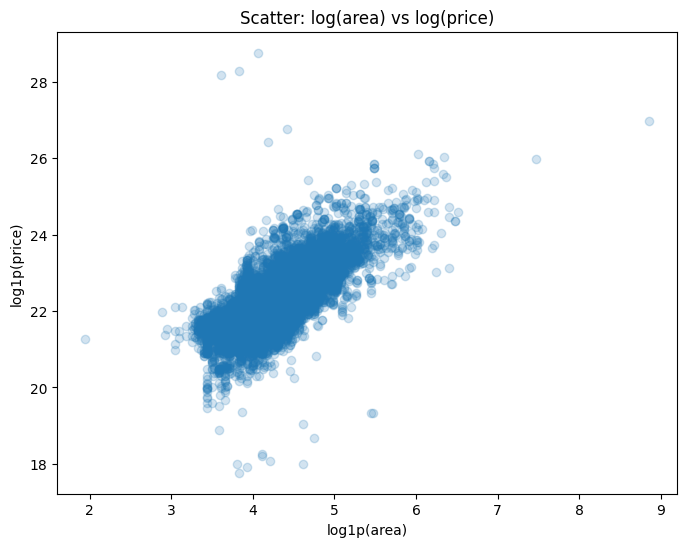

In [38]:
# Quan hệ diện tích - giá
if {"area", "price"}.issubset(eda_valid.columns):
    sample = eda_valid.sample(min(20_000, len(eda_valid)), random_state=42)

    plt.figure(figsize=(8, 6))
    plt.scatter(sample["area"], sample["price"], alpha=0.2)
    plt.title("Scatter: area vs price")
    plt.xlabel("area")
    plt.ylabel("price")
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(np.log1p(sample["area"]), np.log1p(sample["price"]), alpha=0.2)
    plt.title("Scatter: log(area) vs log(price)")
    plt.xlabel("log1p(area)")
    plt.ylabel("log1p(price)")
    plt.show()

### 8.1. Phân tích các đặc điểm vật lý ít được phủ dữ liệu

Ba feature `frontage_width`, `house_depth` và `road_width` tồn tại trong schema nhưng gần như không có dữ liệu đối với tập căn hộ:

- `frontage_width` thiếu khoảng **99,85%** trong `eda_valid`, chỉ có **1.049** dòng có giá trị.
- `house_depth` thiếu khoảng **99,93%**, chỉ có **463** dòng có giá trị.
- `road_width` thiếu khoảng **99,96%**, chỉ có **249** dòng có giá trị.

Các biến này phù hợp hơn với nhà mặt đất/đất nền hơn là căn hộ chung cư. Với tỷ lệ phủ quá thấp, không nên đưa trực tiếp vào mô hình baseline. Nếu vẫn muốn dùng, nên biến đổi thành indicator kiểu `has_frontage_width`, `has_house_depth`, `has_road_width` hoặc loại bỏ để tránh nhiễu và missing-value artifact.

,column,non_missing_count,missing_percent,unique_count,median,p01,p99,max
0,frontage_width,1049,99.85,96,6.00,3.00,62.00,200.00
1,house_depth,463,99.93,108,10.00,2.62,54.42,300.00
2,road_width,249,99.96,41,5.00,2.00,62.00,68.00



Top giá trị của frontage_width:


,count,count
0,5.00,223
1,4.00,126
2,8.00,107
3,6.00,107
4,7.00,103
5,10.00,50
6,3.00,33
7,9.00,26
8,4.50,24
9,3.50,16


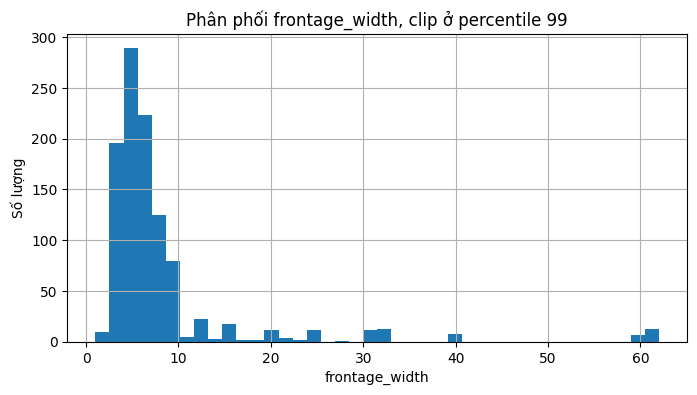


Top giá trị của house_depth:


,count,count
0,10.00,96
1,11.00,55
2,9.00,50
3,12.00,33
4,8.00,28
5,20.00,17
6,14.00,10
7,9.50,9
8,15.00,9
9,8.50,7


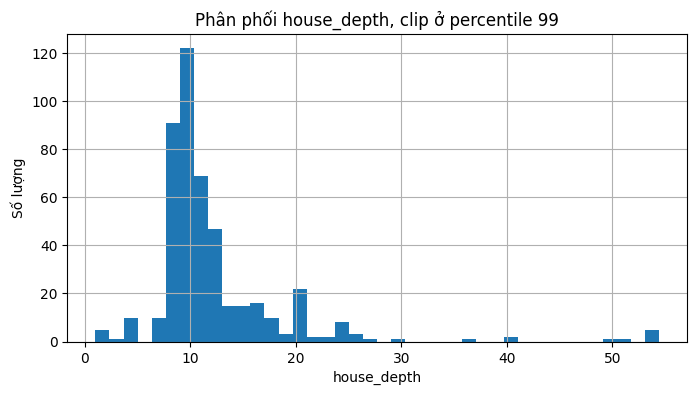


Top giá trị của road_width:


,count,count
0,5.00,49
1,4.00,31
2,3.00,26
3,10.00,23
4,6.00,23
5,8.00,18
6,15.00,10
7,20.00,9
8,2.00,6
9,30.00,4


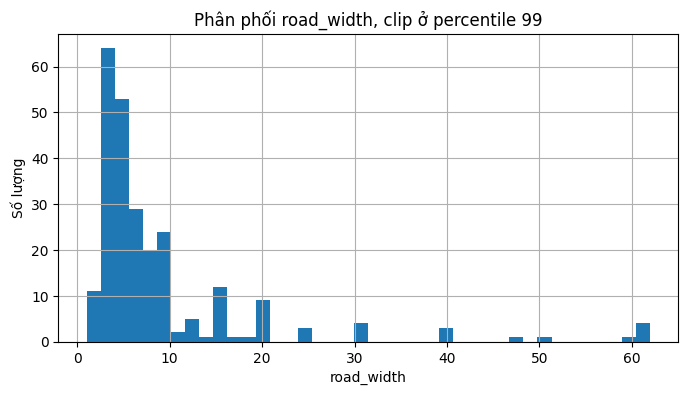

In [39]:
aux_numeric_cols = [col for col in ["frontage_width", "house_depth", "road_width"] if col in eda_valid.columns]

if aux_numeric_cols:
    aux_summary = pd.DataFrame({
        "column": aux_numeric_cols,
        "non_missing_count": [eda_valid[col].notna().sum() for col in aux_numeric_cols],
        "missing_percent": [eda_valid[col].isna().mean() * 100 for col in aux_numeric_cols],
        "unique_count": [eda_valid[col].nunique(dropna=True) for col in aux_numeric_cols],
        "median": [eda_valid[col].median() for col in aux_numeric_cols],
        "p01": [eda_valid[col].quantile(0.01) for col in aux_numeric_cols],
        "p99": [eda_valid[col].quantile(0.99) for col in aux_numeric_cols],
        "max": [eda_valid[col].max() for col in aux_numeric_cols],
    })
    display(aux_summary)

    for col in aux_numeric_cols:
        print(f"\nTop giá trị của {col}:")
        display(eda_valid[col].value_counts(dropna=True).head(15).reset_index().rename(columns={"index": col, col: "count"}))

        s = eda_valid[col].dropna()
        if len(s) > 0:
            plt.figure(figsize=(8, 4))
            s.clip(upper=s.quantile(0.99)).hist(bins=40)
            plt.title(f"Phân phối {col}, clip ở percentile 99")
            plt.xlabel(col)
            plt.ylabel("Số lượng")
            plt.show()
else:
    print("Không có các cột frontage_width, house_depth, road_width")

### 8.2. Phân tích hướng nhà và hướng ban công

`house_direction` và `balcony_direction` có thể ảnh hưởng đến giá căn hộ, nhưng độ phủ chưa tốt:

- `house_direction` thiếu khoảng **56,59%** trong `eda_valid`.
- `balcony_direction` thiếu khoảng **57,90%** trong `eda_valid`.

Các nhóm hướng phổ biến gồm Đông Nam/Đông - Nam, Tây Bắc/Tây - Bắc, Đông Bắc/Đông - Bắc, Nam, Bắc, Tây Nam/Tây - Nam. Có dấu hiệu trùng chuẩn đặt tên, ví dụ `Đông Nam` và `Đông - Nam` đang là hai giá trị khác nhau dù có thể cùng ý nghĩa.

Vì vậy trước khi dùng hai feature này, nên chuẩn hóa nhãn hướng, gom các biến thể tương đương, và tạo nhóm `Unknown` cho giá trị thiếu. Không nên diễn giải chênh lệch giá/m² theo hướng như quan hệ nhân quả, vì hướng có thể bị lẫn với dự án, vị trí và phân khúc căn hộ.

In [40]:
direction_cols = [col for col in ["house_direction", "balcony_direction"] if col in eda_valid.columns]

for col in direction_cols:
    print(f"\nPhân phối {col}:")
    print(f"Tỷ lệ thiếu: {eda_valid[col].isna().mean() * 100:.2f}%")
    display(eda_valid[col].value_counts(dropna=False).head(20).reset_index().rename(columns={"index": col, col: "count"}))

    if "price_per_m2" in eda_valid.columns:
        direction_summary = (
            eda_valid
            .groupby(col, dropna=False)
            .agg(
                count=("price_per_m2", "size"),
                median_price=("price", "median"),
                median_price_per_m2=("price_per_m2", "median")
            )
            .reset_index()
            .sort_values("count", ascending=False)
        )
        display(direction_summary.head(20))


Phân phối house_direction:
Tỷ lệ thiếu: 56.59%


,count,count
0,NaN,383654
1,Đông Nam,40031
2,Tây Bắc,33991
3,Tây - Bắc,29471
4,Đông - Nam,28715
5,Đông Bắc,26752
6,Nam,25919
7,Đông,21091
8,Đông - Bắc,20609
9,Tây Nam,19701


,house_direction,count,median_price,median_price_per_m2
16,NaN,383654,"4,750,000,000.00","66,176,470.59"
15,Đông Nam,40031,"4,990,000,000.00","69,090,909.09"
6,Tây Bắc,33991,"5,780,000,000.00","73,333,333.33"
4,Tây - Bắc,29471,"6,000,000,000.00","74,151,898.73"
12,Đông - Nam,28715,"4,880,000,000.00","68,048,780.49"
14,Đông Bắc,26752,"4,900,000,000.00","70,195,714.39"
1,Nam,25919,"4,600,000,000.00","64,000,000.00"
10,Đông,21091,"4,700,000,000.00","65,685,164.21"
11,Đông - Bắc,20609,"5,000,000,000.00","70,610,687.02"
8,Tây Nam,19701,"5,150,000,000.00","72,570,725.71"



Phân phối balcony_direction:
Tỷ lệ thiếu: 57.90%


,count,count
0,NaN,392509
1,Đông Nam,48264
2,Đông - Nam,46263
3,Nam,26949
4,Đông Bắc,22696
5,Đông - Bắc,21626
6,Tây Bắc,20792
7,Tây - Bắc,19823
8,Tây Nam,18107
9,Bắc,17277


,balcony_direction,count,median_price,median_price_per_m2
15,NaN,392509,"4,700,000,000.00","65,789,473.68"
13,Đông Nam,48264,"5,700,000,000.00","72,580,645.16"
11,Đông - Nam,46263,"5,900,000,000.00","73,417,721.52"
1,Nam,26949,"4,900,000,000.00","67,058,823.53"
12,Đông Bắc,22696,"5,200,000,000.00","71,818,181.82"
9,Đông - Bắc,21626,"5,298,700,000.00","72,299,964.44"
6,Tây Bắc,20792,"5,000,000,000.00","69,047,619.05"
3,Tây - Bắc,19823,"5,050,000,000.00","69,879,518.07"
7,Tây Nam,18107,"5,000,000,000.00","71,250,000.00"
0,Bắc,17277,"4,850,000,000.00","66,666,666.67"


## 9. Phân tích thời gian đăng tin

`published_at` phủ chủ yếu từ **06/2025 đến 03/2026**. Sau khi lọc `price` và `area` hợp lệ, có khoảng **673.261 dòng** parse được thời gian, còn khoảng **4.634 dòng** không parse được.

Dữ liệu có yếu tố thời gian rõ ràng, nên khi đánh giá mô hình có thể cân nhắc chia train/test theo thời gian thay vì chia ngẫu nhiên hoàn toàn. Điều này giúp kiểm tra khả năng dự đoán trên các tin đăng mới hơn và giảm rủi ro leakage theo thời điểm thị trường.

count                        673261
mean     2025-11-05 21:30:24.708858
min      2025-06-01 00:06:26.516000
25%      2025-08-26 14:49:13.107000
50%      2025-11-07 17:19:21.233000
75%      2026-01-07 13:49:35.658000
max      2026-03-30 23:53:52.077000
Name: published_at_dt, dtype: object


published_year
2,025.00    484134
2,026.00    189127
NaN           4634
Name: count, dtype: int64

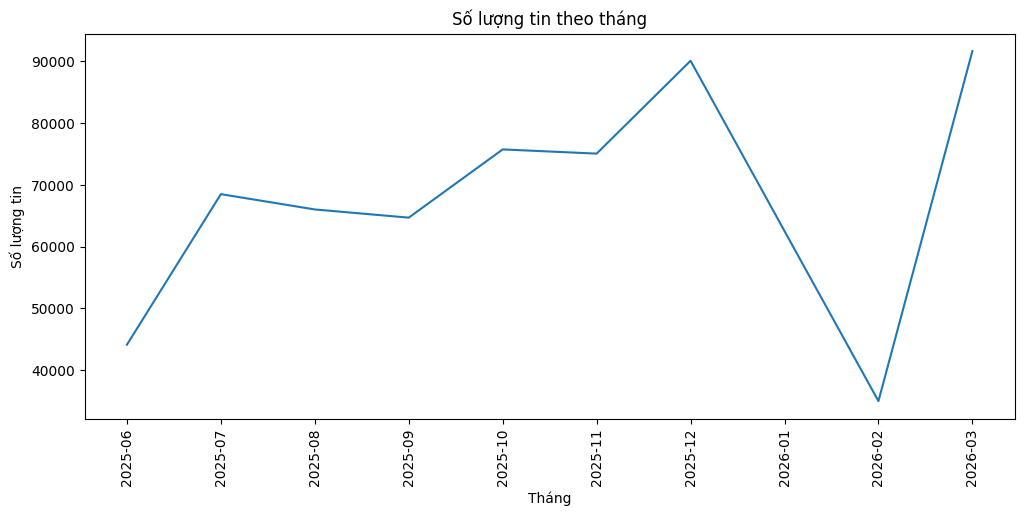

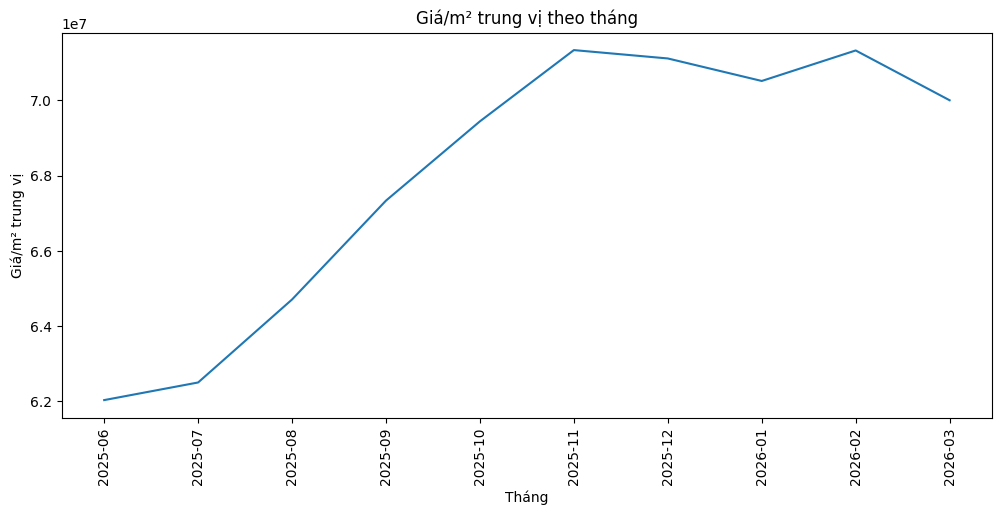

In [41]:
if "published_at" in eda_valid.columns:
    eda_valid["published_at_dt"] = pd.to_datetime(eda_valid["published_at"], errors="coerce")
    print(eda_valid["published_at_dt"].describe())

    eda_valid["published_year"] = eda_valid["published_at_dt"].dt.year
    eda_valid["published_month"] = eda_valid["published_at_dt"].dt.to_period("M").astype(str)

    display(eda_valid["published_year"].value_counts(dropna=False).sort_index())

    monthly_count = eda_valid["published_month"].value_counts().sort_index()

    plt.figure(figsize=(12, 5))
    plt.plot(monthly_count.index, monthly_count.values)
    plt.title("Số lượng tin theo tháng")
    plt.xlabel("Tháng")
    plt.ylabel("Số lượng tin")
    plt.xticks(rotation=90)
    plt.show()

    if "price_per_m2" in eda_valid.columns:
        monthly_price = (
            eda_valid
            .groupby("published_month")
            .agg(
                count=("price_per_m2", "size"),
                median_price_per_m2=("price_per_m2", "median")
            )
            .reset_index()
        )
        monthly_price = monthly_price[monthly_price["count"] >= 100]

        plt.figure(figsize=(12, 5))
        plt.plot(monthly_price["published_month"], monthly_price["median_price_per_m2"])
        plt.title("Giá/m² trung vị theo tháng")
        plt.xlabel("Tháng")
        plt.ylabel("Giá/m² trung vị")
        plt.xticks(rotation=90)
        plt.show()
else:
    print("Không có cột published_at")

## 10. Phân tích văn bản mô tả

`name` và `description` có độ phủ tốt: không thiếu trong dữ liệu gốc. Độ dài trung vị của `name` khoảng **84 ký tự**, còn `description` khoảng **545 ký tự**, đủ để khai thác đặc trưng văn bản.

Một số keyword xuất hiện nhiều và có thể liên quan đến giá/m² như `nội thất`, `ban công`, `cao cấp`, `view sông`, `duplex`, `penthouse`. Vì vậy nên thử thêm đặc trưng text đơn giản như TF-IDF/keyword flags, rồi so sánh với mô hình chỉ dùng dữ liệu bảng.


Thống kê độ dài name:


count   677,895.00
mean         80.13
std          16.41
min           0.00
25%          69.00
50%          84.00
75%          94.00
95%          99.00
99%         102.00
max         120.00
Name: name_length, dtype: float64

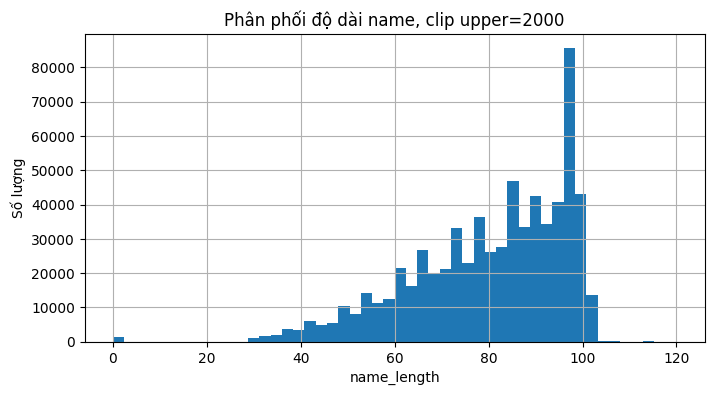


Thống kê độ dài description:


count   677,895.00
mean        652.62
std         457.77
min           0.00
25%         314.00
50%         545.00
75%         857.00
95%       1,529.00
99%       2,354.00
max       4,865.00
Name: description_length, dtype: float64

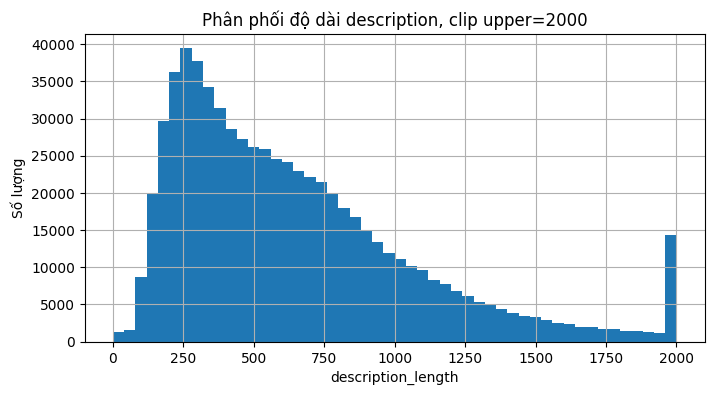

In [42]:
for col in ["name", "description"]:
    if col in eda_valid.columns:
        eda_valid[f"{col}_length"] = eda_valid[col].fillna("").astype(str).str.len()

        print(f"\nThống kê độ dài {col}:")
        display(eda_valid[f"{col}_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

        plt.figure(figsize=(8, 4))
        eda_valid[f"{col}_length"].clip(upper=2000).hist(bins=50)
        plt.title(f"Phân phối độ dài {col}, clip upper=2000")
        plt.xlabel(f"{col}_length")
        plt.ylabel("Số lượng")
        plt.show()

In [43]:
# Kiểm tra một số keyword tiện ích/cụm từ có thể ảnh hưởng đến giá
if "description" in eda_valid.columns:
    text_series = eda_valid["description"].fillna("").astype(str).str.lower()

    keywords = [
        "full nội thất", "nội thất", "view sông", "view biển", "ban công",
        "sổ hồng", "pháp lý", "gần trường", "gần chợ", "trung tâm",
        "metro", "cao cấp", "luxury", "duplex", "penthouse"
    ]

    rows = []
    for kw in keywords:
        mask = text_series.str.contains(kw, regex=False)
        rows.append({
            "keyword": kw,
            "count": mask.sum(),
            "percent": mask.mean() * 100,
            "median_price": eda_valid.loc[mask, "price"].median() if "price" in eda_valid.columns else np.nan,
            "median_price_per_m2": eda_valid.loc[mask, "price_per_m2"].median() if "price_per_m2" in eda_valid.columns else np.nan,
        })

    keyword_df = pd.DataFrame(rows).sort_values("count", ascending=False)
    display(keyword_df)
else:
    print("Không có cột description")

,keyword,count,percent,median_price,median_price_per_m2
1,nội thất,385038,56.80,"5,300,000,000.00","71,022,727.27"
6,pháp lý,225699,33.29,"4,900,000,000.00","67,600,000.00"
4,ban công,210714,31.08,"5,550,000,000.00","71,739,130.43"
9,trung tâm,196114,28.93,"4,750,000,000.00","66,666,666.67"
11,cao cấp,157016,23.16,"5,900,000,000.00","75,485,837.92"
5,sổ hồng,121237,17.88,"4,200,000,000.00","58,490,566.04"
0,full nội thất,105206,15.52,"5,400,000,000.00","72,468,831.77"
2,view sông,36848,5.44,"6,300,000,000.00","80,851,063.83"
10,metro,36774,5.42,"4,100,000,000.00","61,810,961.41"
7,gần trường,35308,5.21,"4,800,000,000.00","65,714,285.71"


## 11. Tạo bảng đánh giá chất lượng dữ liệu

Bảng này tóm tắt chất lượng dữ liệu cho báo cáo. Nhìn chung dataset đủ lớn và có đủ các trường nền tảng cho bài toán dự đoán giá, nhưng cần lưu ý ba vấn đề chính:

- `price` thiếu khoảng **8,26%**, các dòng này không dùng trực tiếp để train supervised regression.
- Một số biến vị trí/dự án thiếu ở mức vừa đến cao, đặc biệt `street_name` và `project_name`.
- Một số biến vật lý/hướng thiếu rất nhiều, nhất là `floor_count`, `house_direction`, `balcony_direction`.

Do đó dataset phù hợp để làm mô hình, nhưng cần bước xử lý thiếu dữ liệu, outlier và kiểm tra bias địa lý trước khi kết luận hiệu năng.

In [44]:
quality_rows = []

def add_quality_metric(name, value, comment):
    quality_rows.append({
        "Tiêu chí": name,
        "Giá trị": value,
        "Nhận xét": comment
    })

add_quality_metric("Số dòng ban đầu", len(df), "Quy mô dữ liệu càng lớn càng thuận lợi cho mô hình học máy.")
add_quality_metric("Số dòng có price và area hợp lệ", len(eda_valid), "Đây là phần dữ liệu có thể dùng trực tiếp cho bài toán regression sau xử lý thêm.")

if "price" in df.columns:
    add_quality_metric("Tỷ lệ thiếu price", f"{df['price'].isna().mean() * 100:.2f}%", "Price là biến mục tiêu, dòng thiếu price không dùng để train supervised learning.")

if "area" in df.columns:
    add_quality_metric("Tỷ lệ thiếu area", f"{df['area'].isna().mean() * 100:.2f}%", "Area là biến rất quan trọng để dự đoán giá.")

if "province_name" in df.columns:
    add_quality_metric("Số tỉnh/thành", df["province_name"].nunique(dropna=True), "Cho biết độ phủ địa lý của dataset.")

if "district_name" in df.columns:
    add_quality_metric("Số quận/huyện", df["district_name"].nunique(dropna=True), "Dữ liệu vị trí chi tiết giúp tăng khả năng dự đoán.")

if "project_name" in df.columns:
    add_quality_metric("Tỷ lệ thiếu project_name", f"{df['project_name'].isna().mean() * 100:.2f}%", "Project_name thường rất quan trọng với căn hộ chung cư.")

if "description" in df.columns:
    add_quality_metric("Tỷ lệ thiếu description", f"{df['description'].isna().mean() * 100:.2f}%", "Description có thể dùng để trích đặc trưng văn bản.")

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

,Tiêu chí,Giá trị,Nhận xét
0,Số dòng ban đầu,762800,Quy mô dữ liệu càng lớn càng thuận lợi cho mô ...
1,Số dòng có price và area hợp lệ,677895,Đây là phần dữ liệu có thể dùng trực tiếp cho ...
2,Tỷ lệ thiếu price,8.26%,"Price là biến mục tiêu, dòng thiếu price không..."
3,Tỷ lệ thiếu area,0.00%,Area là biến rất quan trọng để dự đoán giá.
4,Số tỉnh/thành,53,Cho biết độ phủ địa lý của dataset.
5,Số quận/huyện,198,Dữ liệu vị trí chi tiết giúp tăng khả năng dự ...
6,Tỷ lệ thiếu project_name,12.54%,Project_name thường rất quan trọng với căn hộ ...
7,Tỷ lệ thiếu description,0.00%,Description có thể dùng để trích đặc trưng văn...


## 12. Gợi ý tập dữ liệu sau làm sạch sơ bộ

Cell này tạo một bản dữ liệu sạch sơ bộ để dùng thử mô hình baseline. Với ngưỡng percentile 1%–99% cho `area` và `price_per_m2`, còn **654.217 dòng**, tương đương **96,51%** của `eda_valid` và khoảng **85,77%** dữ liệu ban đầu.

Bản clean này phù hợp để chạy baseline nhanh. Khi làm mô hình chính, nên thử thêm các kịch bản ngưỡng khác và kiểm tra metric theo từng tỉnh/thành để tránh việc lọc quá mạnh ở các phân khúc cao cấp hoặc địa phương có mặt bằng giá khác biệt.

In [45]:
clean_df = eda_valid.copy()

if {"area", "price", "price_per_m2"}.issubset(clean_df.columns):
    # Lọc theo percentile để bỏ cực trị quá bất thường
    area_low, area_high = clean_df["area"].quantile([0.01, 0.99])
    ppm2_low, ppm2_high = clean_df["price_per_m2"].quantile([0.01, 0.99])

    clean_df = clean_df[
        (clean_df["area"].between(area_low, area_high)) &
        (clean_df["price_per_m2"].between(ppm2_low, ppm2_high))
    ].copy()

    print("Shape sau clean sơ bộ:", clean_df.shape)
    print("Tỷ lệ giữ lại so với eda_valid:", len(clean_df) / len(eda_valid) * 100, "%")

    output_path = Path("data/vietnam_apartments_clean_eda.parquet")
    clean_df.to_parquet(output_path, index=False)

    print("Đã lưu file clean sơ bộ:", output_path)
else:
    print("Không đủ cột để tạo clean_df")

Shape sau clean sơ bộ: (654217, 25)
Tỷ lệ giữ lại so với eda_valid: 96.50712868512085 %
Đã lưu file clean sơ bộ: data/vietnam_apartments_clean_eda.parquet


## 13. Kết luận EDA đưa vào báo cáo


Kết luận chính từ kết quả thực tế:

1. Dataset đủ lớn cho bài toán học máy: **762.800 tin căn hộ**, trong đó **677.895 tin** có `price` và `area` hợp lệ.
2. Dữ liệu đã đúng phạm vi căn hộ/chung cư: toàn bộ bản ghi có `property_type_name = Căn hộ chung cư`.
3. Các cột cốt lõi `price`, `area`, `province_name`, `district_name`, `project_name`, `name`, `description` có thể dùng được. `area`, `province_name`, `name`, `description` gần như đầy đủ; `price` thiếu khoảng **8,26%**; `project_name` thiếu khoảng **12,54%**.
4. Một số cột không nên phụ thuộc quá nhiều: `floor_count` thiếu gần như toàn bộ; `frontage_width`, `house_depth`, `road_width` thiếu trên 99%; `house_direction` và `balcony_direction` thiếu trên 50%; `street_name` thiếu gần 48%.
5. Phân phối `price`, `area` và `price_per_m2` lệch phải mạnh, có cực trị rất lớn. Nên dùng `log(price)` hoặc `log1p(price)` làm target trong mô hình regression.
6. Quy tắc lọc outlier sơ bộ theo percentile 1%–99% giữ lại **654.217 dòng**. Đây là tập đủ lớn để chạy baseline, nhưng cần mô tả rõ ngưỡng lọc trong báo cáo.
7. Dữ liệu thiên lệch địa lý rõ rệt về **Hồ Chí Minh** và **Hà Nội**. Nếu báo cáo là cho “toàn Việt Nam”, cần ghi rõ mô hình có thể đáng tin hơn ở các thị trường nhiều mẫu.
8. `street_name` có thể bổ sung tín hiệu vị trí chi tiết, nhưng cần mã hóa cẩn thận vì thiếu khoảng **48,20%** và có cardinality cao.
9. Văn bản mô tả có giá trị khai thác: `description` không thiếu, độ dài trung vị khoảng **545 ký tự**, nhiều keyword liên quan đến tiện ích/phân khúc như `nội thất`, `cao cấp`, `view sông`, `duplex`, `penthouse`.
10. Baseline nên bắt đầu bằng mô hình đơn giản: median giá/m² theo tỉnh/quận/dự án hoặc Linear/Ridge Regression trên `log(price)`.
11. Mô hình chính nên thử các mô hình cây tăng cường như LightGBM/CatBoost/XGBoost, vì dữ liệu có nhiều biến categorical, missing value và quan hệ phi tuyến. Sau đó so sánh thêm phiên bản có đặc trưng text.
12. Dataset phù hợp cho bài toán dự đoán giá căn hộ chung cư, nhưng kết luận nên giới hạn trong phạm vi dữ liệu tin đăng online, có thiên lệch địa lý và cần xử lý outlier trước khi huấn luyện mô hình chính.